In [1]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [2]:
print(df.shape)

(716165, 12)


There are 71616 rows in this dataset, + 1 for the header. 

In [5]:
na_hurricanes = df[df['BASIN'] == 'NA']['SID'].nunique()
print(na_hurricanes)

2344


There are 2344 North Atlantic hurricanes in this dataset

In [6]:
for col in ['BASIN', 'SUBBASIN', 'NATURE']:
    print(df[col].unique())

['NI' 'SI' 'NA' 'EP' 'WP' 'SP' 'SA']
['BB' 'AS' 'MM' 'GM' 'NA' 'CS' 'WA' 'EA' 'CP']
['NR' 'TS' 'ET' 'SS' 'MX' 'DS']


In [9]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


In [11]:
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


In [12]:
storm_max = df.groupby('SID')['WIND'].max()
top10 = storm_max.nlargest(10)

print(top10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64


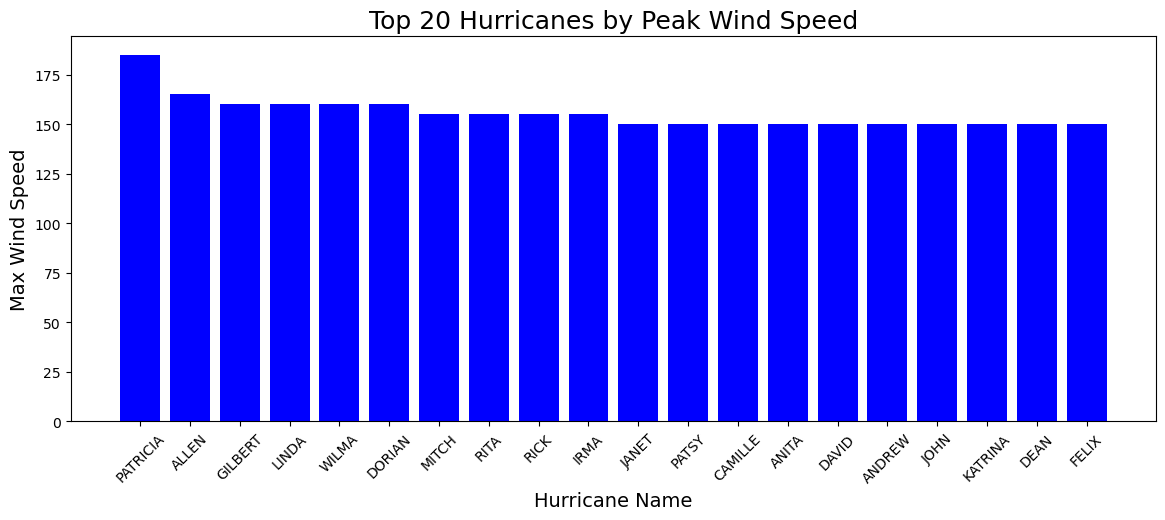

In [30]:
import numpy as np
import matplotlib.pyplot as plt
storm_max = df.groupby('SID').agg(WIND=('WIND', 'max'), NAME=('NAME', 'first')).reset_index()
storm_max = storm_max.dropna(subset=['NAME'])
top20 = storm_max.nlargest(20, 'WIND')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top20['NAME'], top20['WIND'], color='blue')
ax.set_title('Top 20 Hurricanes by Peak Wind Speed', fontsize=18)
ax.set_xlabel('Hurricane Name', fontsize=14)
ax.set_ylabel('Max Wind Speed', fontsize=14)
plt.xticks(rotation=45)

plt.show()

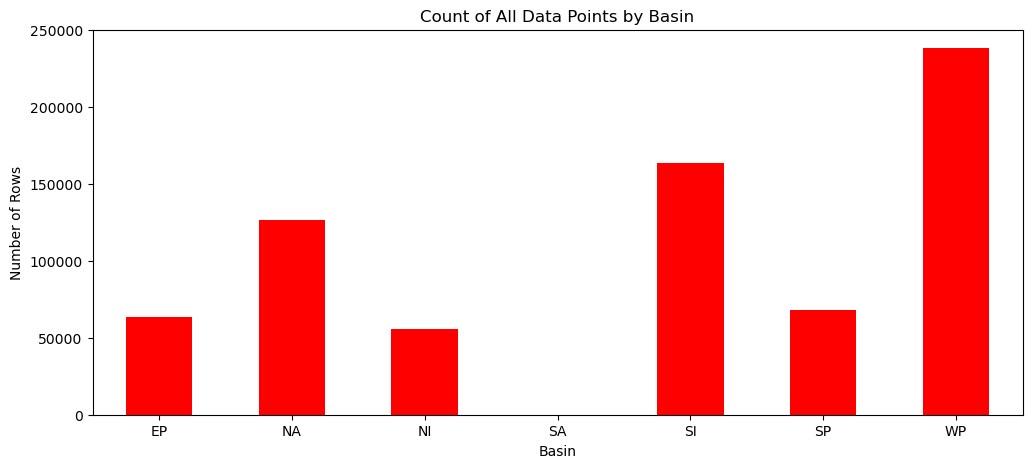

In [31]:
basin_counts = df.groupby('BASIN').size()

fig, ax = plt.subplots(figsize=(12, 5))
basin_counts.plot(kind='bar', ax=ax, color='red')
ax.set_title('Count of All Data Points by Basin')
ax.set_xlabel('Basin')
ax.set_ylabel('Number of Rows')
plt.xticks(rotation=0)
plt.show()

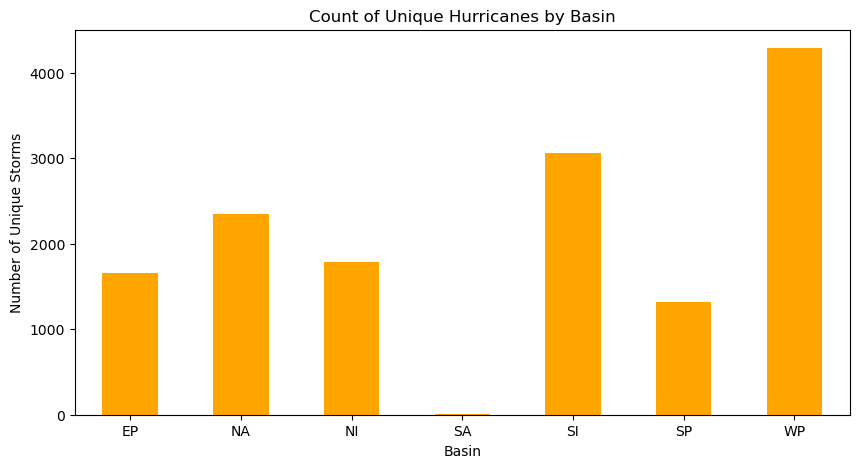

In [33]:

unique_storms = df.groupby('BASIN')['SID'].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
unique_storms.plot(kind='bar', ax=ax, color='orange')
ax.set_title('Count of Unique Hurricanes by Basin')
ax.set_xlabel('Basin')
ax.set_ylabel('Number of Unique Storms')
plt.xticks(rotation=0)

plt.show()

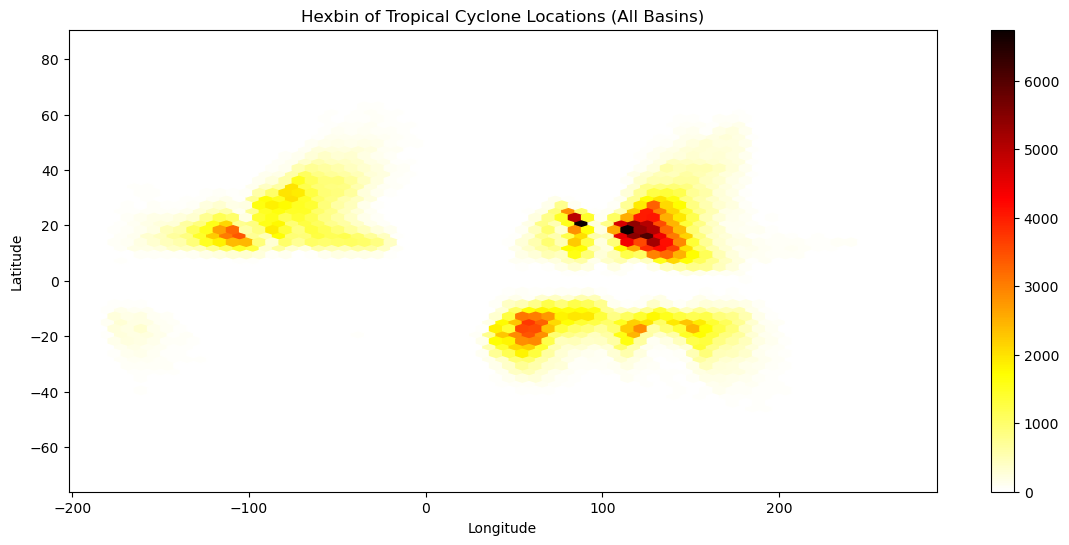

In [41]:
fig, ax = plt.subplots(figsize=(14, 6))
df.plot.hexbin(
    x='LON', y='LAT', cmap='hot_r',
    gridsize=60,
    ax=ax
)
ax.set_title('Hexbin of Tropical Cyclone Locations (All Basins)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

In [37]:
katrina_rows = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)]
katrina_sid = katrina_rows['SID'].iloc[0]
print(katrina_sid)

2005236N23285


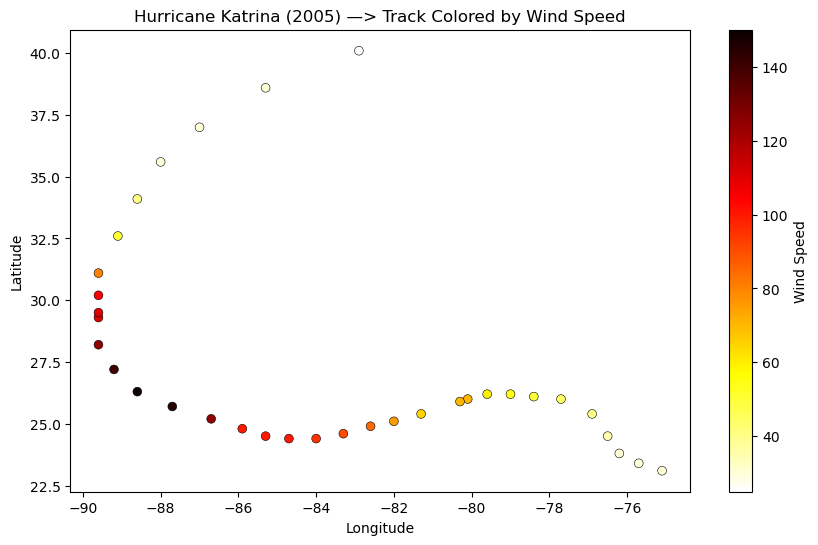

In [45]:
katrina = df[df['SID'] == katrina_sid]
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    katrina['LON'], katrina['LAT'],
    c=katrina['WIND'], cmap='hot_r',
    s=40, edgecolors='black',linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Wind Speed')
ax.set_title('Hurricane Katrina (2005) —> Track Colored by Wind Speed')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

In [46]:
df = df.set_index('ISO_TIME')
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


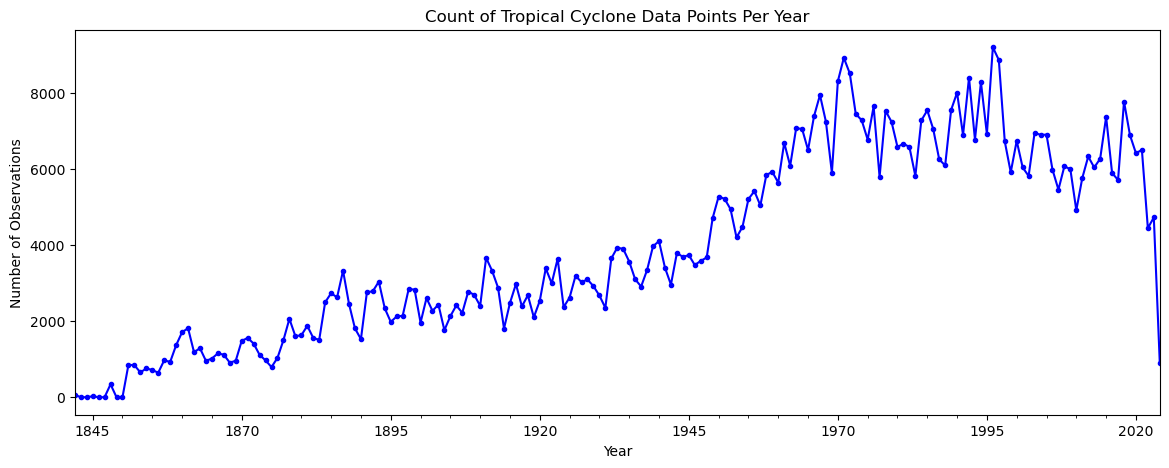

In [54]:
annual_counts = df.resample('YE').size()

fig, ax = plt.subplots(figsize=(14, 5))
annual_counts.plot(ax=ax, color='blue', linewidth=1.5, marker='o', markersize=3)
ax.set_title('Count of Tropical Cyclone Data Points Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Observations')

plt.show()

The main years that stand out as an anomoly are the early 1970s and late 1990s. Most recently the largest spike in hurricanes was a little before 2020. 